In [250]:
import pandas as pd
import chardet
import matplotlib.pyplot as plt

In [251]:
# Функция для загрузки одного файла
def load_csv(file_path, decimal='.'):
    # Определяем кодировку
    with open(file_path, 'rb') as f:
        encoding = chardet.detect(f.read())['encoding']
    
    # Загружаем файл
    df = pd.read_csv(file_path, encoding=encoding, sep=';', decimal=decimal)
    return df

In [252]:
# Загружаем все 5 файлов
df1 = load_csv('data/1.csv')
df2 = load_csv('data/2.csv')
df3 = load_csv('data/3.csv', decimal=',')
df4 = load_csv('data/4.csv')
df5 = load_csv('data/5.csv')

dfs = [df1, df2, df3, df4, df5]

In [253]:
# Удаляем пустой столбец из df3
dfs[2].drop(dfs[2].columns[40], axis=1, inplace=True)

In [254]:
for df in dfs:
    print(df.shape)

(12659, 24)
(13720, 24)
(14896, 40)
(13743, 24)
(38089, 24)


In [255]:
# Приводим столбец времени к одному названию "t" и переводим время в python-объект для удобной работы
for df in dfs:
    cols = df.columns.tolist()
    cols[0] = 't'
    df.columns = cols
    df['t'] = pd.to_datetime(df["t"], format='%H:%M:%S.%f').dt.time

In [256]:
for i, df in enumerate(dfs):
    print("=" * 20, f"{i}.csv", "=" * 20, "\n")
    print(df.describe())

==================== 0.csv ==================== 

       Температура масла в магистрали общей откачки (поз. Тм)  \
count                                       12659.000000        
mean                                           33.339443        
std                                             6.211664        
min                                            21.548000        
25%                                            28.545000        
50%                                            33.543000        
75%                                            38.621500        
max                                            43.561000        

       Температура слива масла из опоры турбины (поз. Т606)  \
count                                       12659.000000      
mean                                           46.899381      
std                                            10.560371      
min                                            28.160000      
25%                                            38

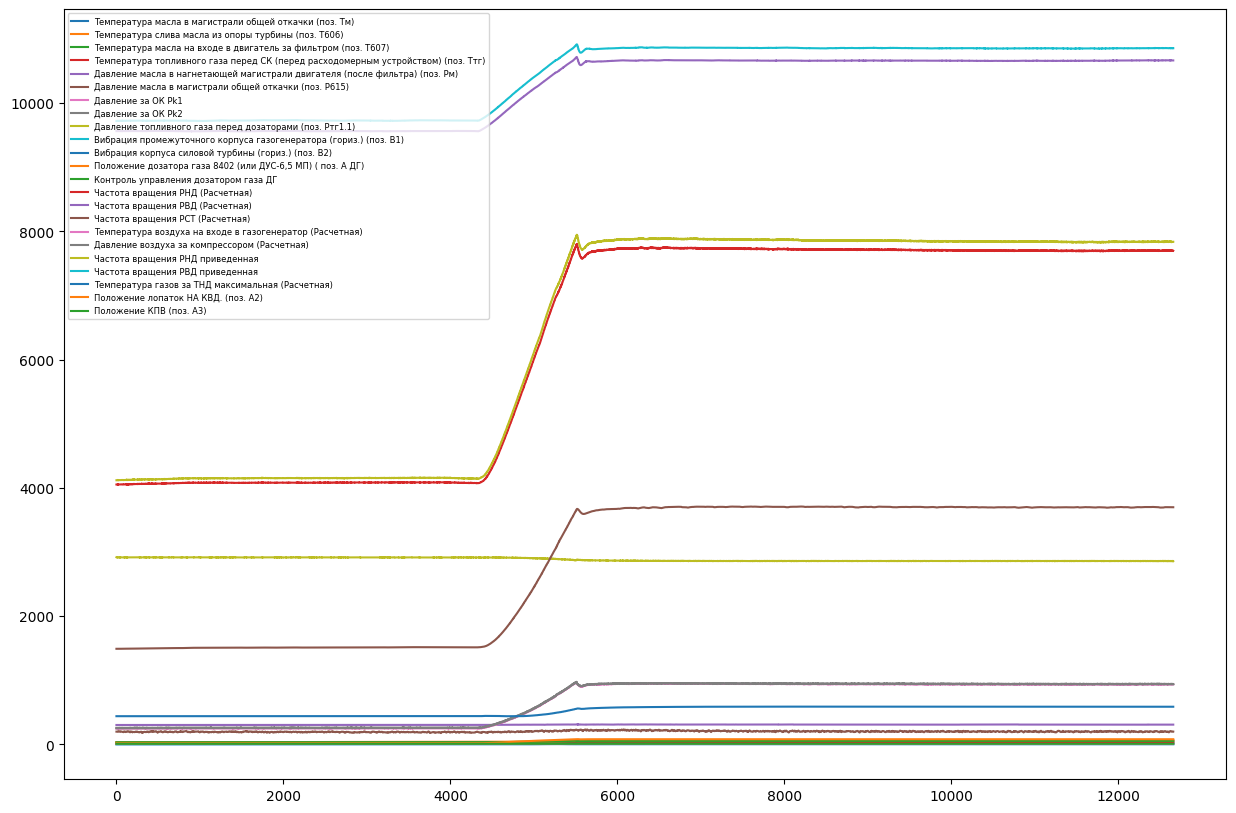

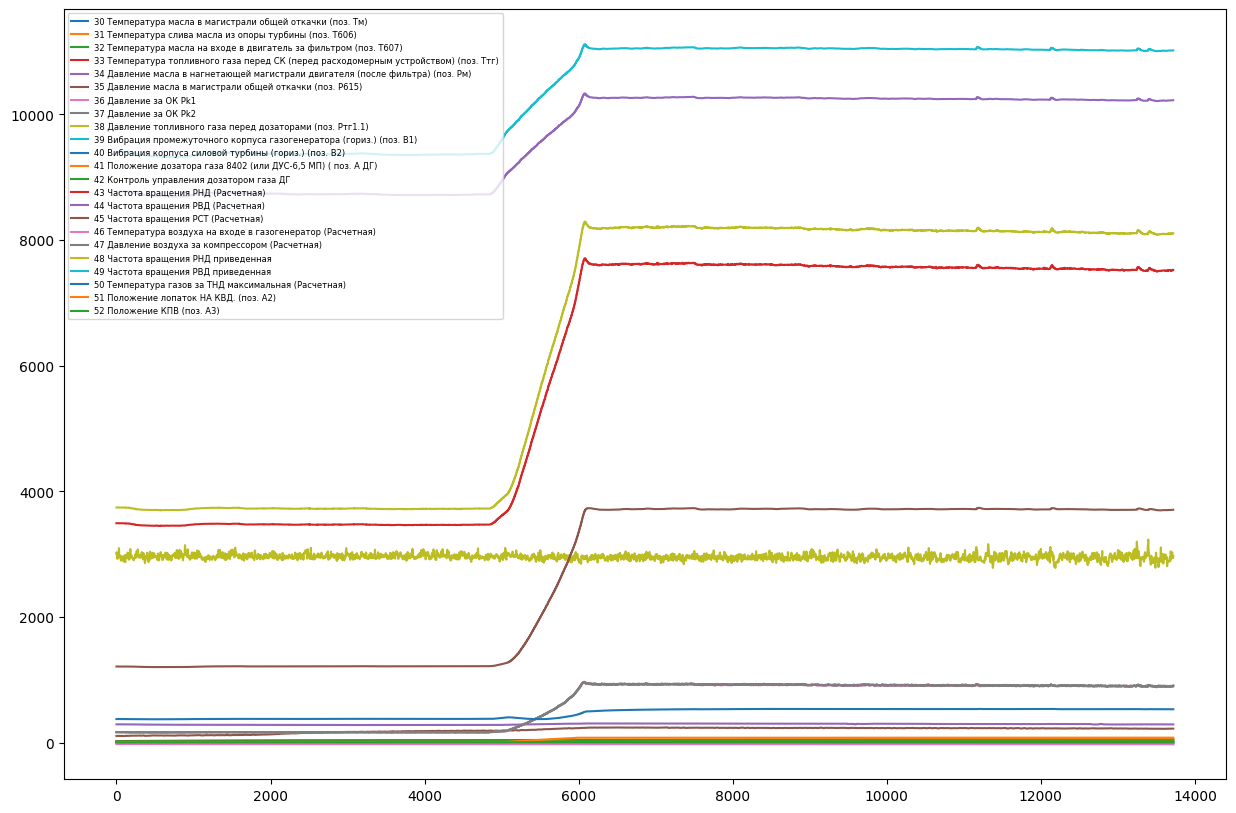

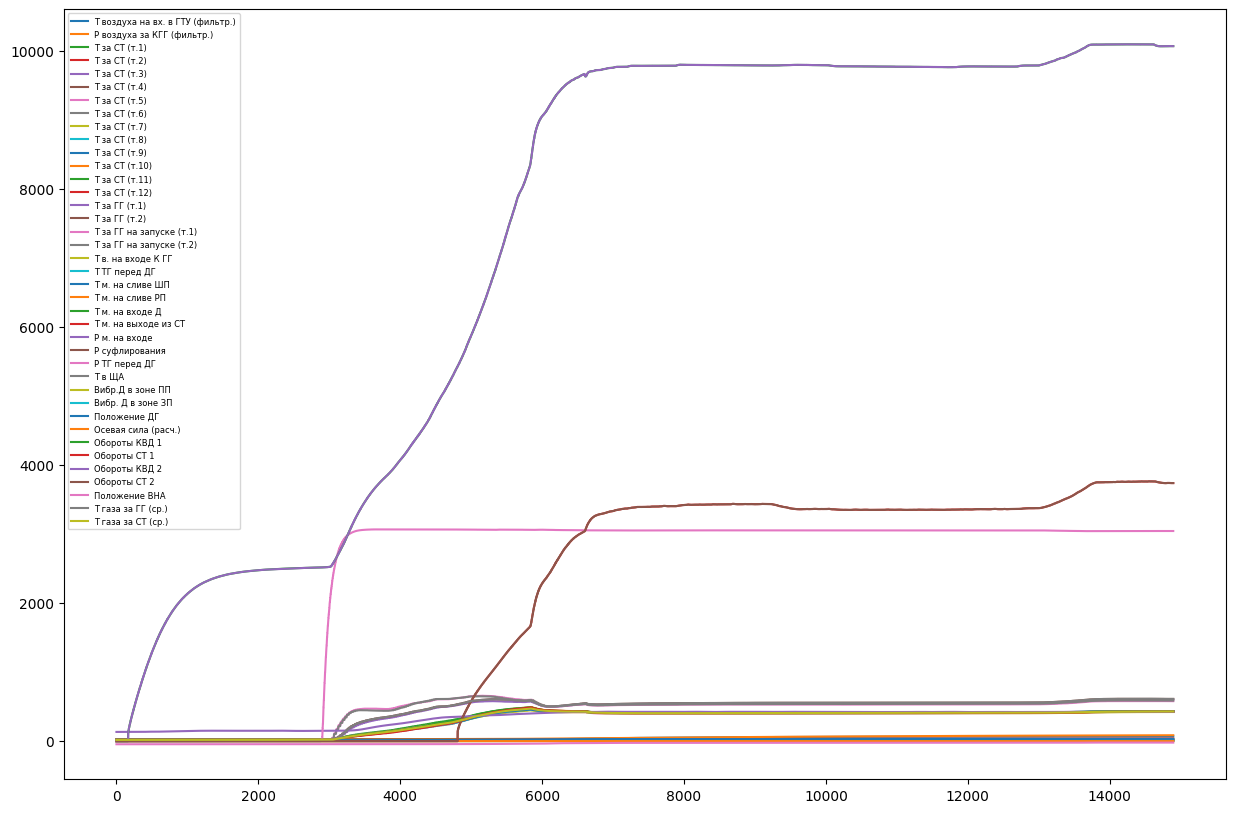

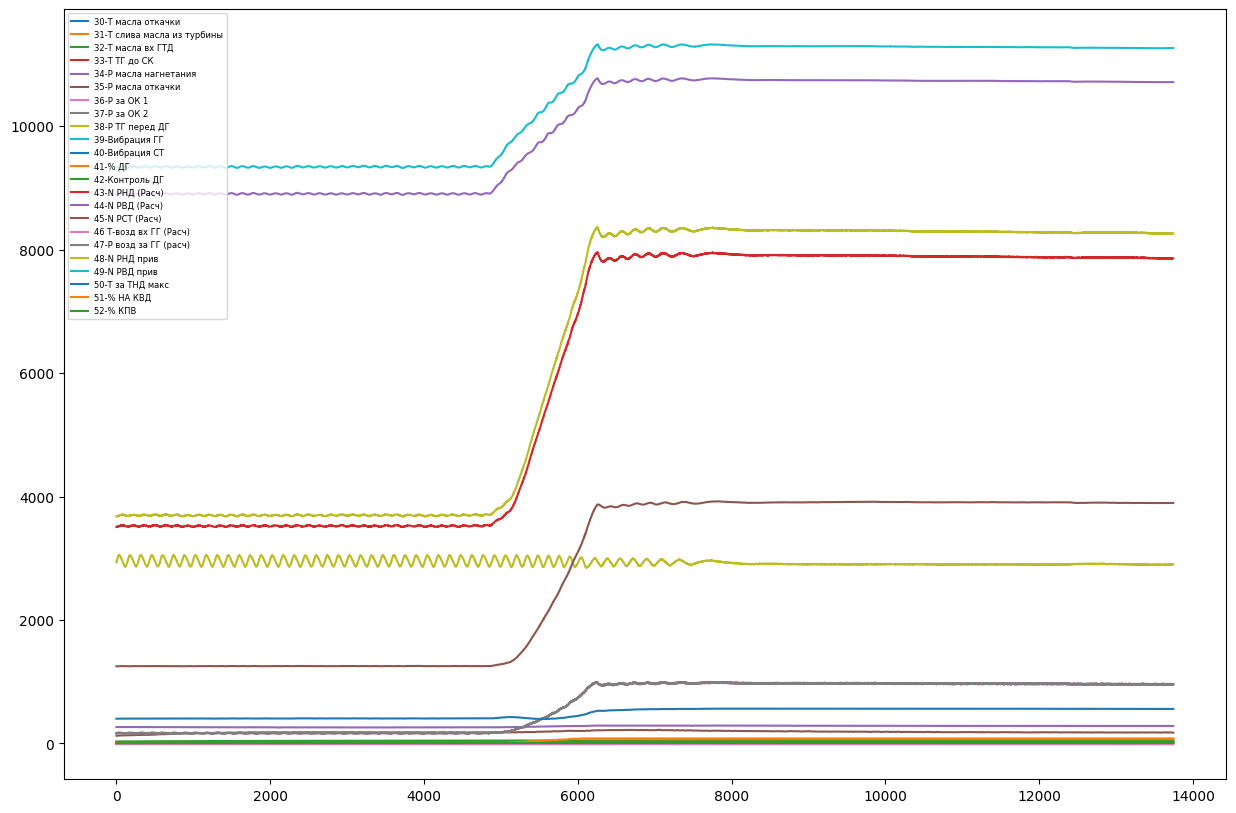

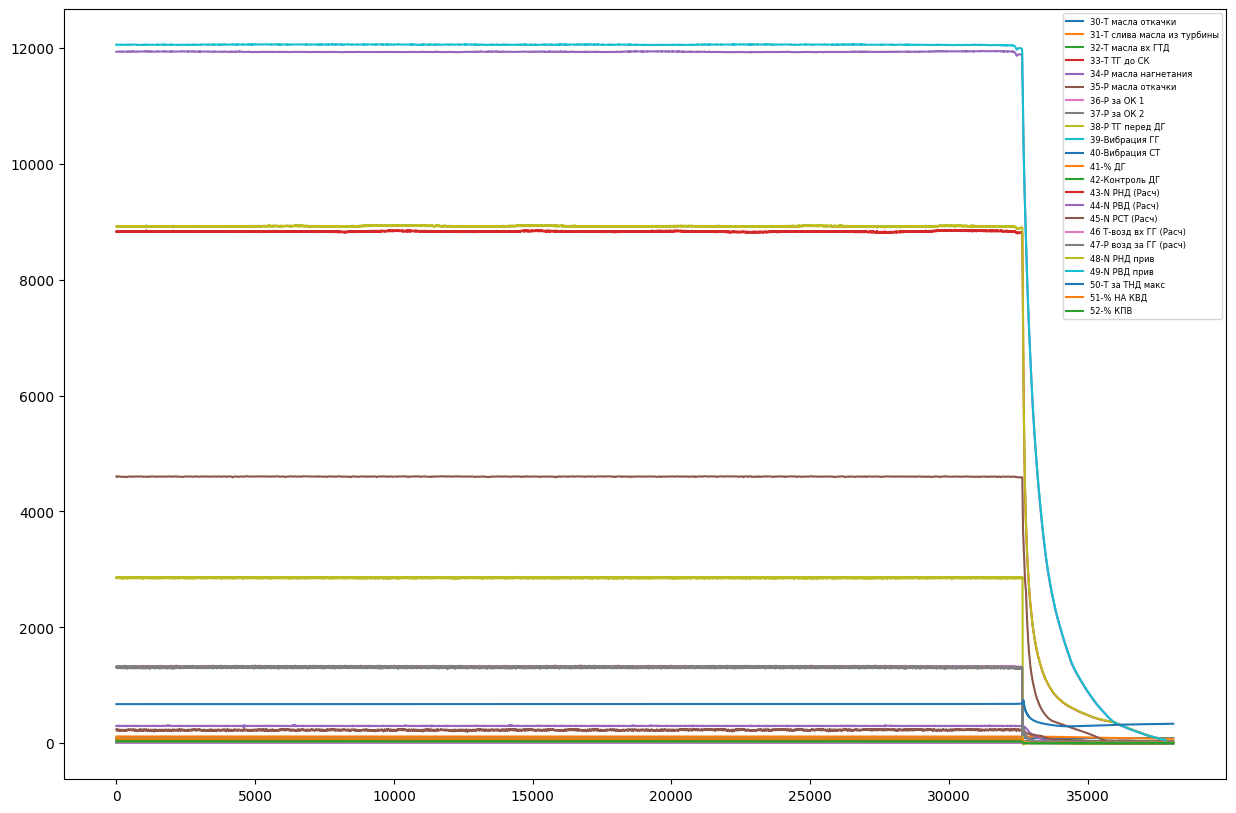

In [257]:
for df in dfs:
    df.plot(figsize=(15, 10))
    plt.legend(fontsize=6)
    plt.show()